In [1]:
import os
import sys
import gc
import json
import time
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from pathlib import Path
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import fbeta_score, balanced_accuracy_score, f1_score, precision_recall_fscore_support

import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import Adam 

device = torch.device("cuda" if torch.cuda.is_available() else 
                     ("mps" if torch.backends.mps.is_available() else "cpu"))

def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *
from Utils.lookahead import Lookahead

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")

Using device: mps


In [4]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [5]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [6]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [7]:
# Define transforms (fixing the syntax error from before)
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
CLASSES = sorted(train["class"].unique().tolist())

In [10]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x13ed3e490>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x10744f6d0>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x107485c10>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x13ee9be10>}

In [ ]:
train_loader = loaders["train_loader_mild"]
val_loader   = loaders["val_loader"]
test_loader  = loaders["test_loader"]

toxic_idx = train_class_to_idx['toxic']

In [13]:
class_weights = torch.tensor([1.0, 1.0, 8.0], dtype=torch.float32, device=device)

In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

## Training and Validation

### Load RESNET50 Model

In [15]:
def run_one_epoch(model, loader, criterion, optimizer, device, is_train=False, return_preds=False, scheduler=None):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    model.train() if is_train else model.eval()
    num_batches = len(loader)
    
    for i, (img, labels) in enumerate(loader):
        img, labels = img.to(device), labels.to(device)

        with torch.set_grad_enabled(is_train):
            outputs = model(img)
            loss = criterion(outputs, labels)
            
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                if scheduler: scheduler.step()

        preds = outputs.argmax(1)
        running_loss += loss.item() * img.size(0)
        running_correct += (preds == labels).sum().item()
        total += img.size(0)

        if (i + 1) % 5 == 0 or (i + 1) == num_batches:
            print(f"  {'Train' if is_train else 'Val'} [{i+1}/{num_batches}] Loss: {loss.item():.4f}", end='\r')

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    print() 
    avg_loss = running_loss / total
    avg_acc = running_correct / total

    if return_preds:
        y_true = torch.cat(all_labels).numpy()
        y_pred = torch.cat(all_preds).numpy()
        
        # Metrics Calculation
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        f1_m = f1_score(y_true, y_pred, average='macro')
        f1_w = f1_score(y_true, y_pred, average='weighted')
        
        # F2 since safety first
        prec, rec, f2_score, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[toxic_idx], beta=2.0, zero_division=0
        )
        _, _, f1_tox, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[toxic_idx], beta=1.0, zero_division=0
        )
        
        metrics = (avg_loss, avg_acc, bal_acc, f1_m, f1_w, prec[0], rec[0], f1_tox[0], f2_score[0])
        return metrics, y_true, y_pred
    
    return (avg_loss, avg_acc, None, None, None, None, None, None, None), None, None

In [16]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_best.pth"
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

In [17]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5, scheduler=None):
    best_priority = -float("inf")
    bad_epochs = 0

    for epoch in range(num_epochs):
        # training dataset
        t_metrics, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True, scheduler=scheduler
        )
        t_loss, t_acc = t_metrics[0], t_metrics[1]
        
        # validation dataset
        v_metrics, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False, return_preds=True
        )
        v_loss, v_acc, v_bal, v_f1_m, v_f1_w, v_tox_p, v_tox_r, v_tox_f1, v_prio = v_metrics

        current_lr = optimizer.param_groups[-1]['lr']

        print(f"\n{'='*20} EPOCH {epoch+1} {'='*20}")
        print(f"TRAIN: Loss {t_loss:.4f} | Acc {t_acc:.4f}")
        print(f"VAL:   Loss {v_loss:.4f} | Acc {v_acc:.4f} | Balanced: {v_bal:.4f}")
        print(f"TOXIC: Recall: {v_tox_r:.4f} | F2 (Safety): {v_prio:.4f}")
        print(f"LR:    {current_lr:.8f}")

        # Early Stopping Logic
        if v_prio > best_priority:
            best_priority = v_prio
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(">>> New Best Model Saved!")
        else:
            bad_epochs += 1
            print(f"No improvement. Patience: {bad_epochs}/{patience}")
            if bad_epochs >= patience:
                print(f"!!! Early stopping triggered.")
                break
        
        clear_memory()

    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [18]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

In [19]:
base_opt = torch.optim.RAdam([
    {"params": model.conv1.parameters(), "lr": 1e-5},
    {"params": model.bn1.parameters(), "lr": 1e-5},
    {"params": model.layer1.parameters(), "lr": 1e-5},
    {"params": model.layer2.parameters(), "lr": 2e-5},
    {"params": model.layer3.parameters(), "lr": 5e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
], weight_decay=0.01)

optimizer = Lookahead(base_opt, k=5, alpha=0.5)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    base_opt, 
    max_lr=[1e-5, 1e-5, 1e-5, 2e-5, 5e-5, 1e-4, 1e-3], 
    steps_per_epoch=len(train_loader), 
    epochs=30
)

In [20]:
model = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device=device, patience=5, scheduler=scheduler)

  Train [151/151] Loss: 0.9839
  Val [19/19] Loss: 1.0027

==================== EPOCH 1 ====================
TRAIN: Loss 1.0678 | Acc 0.3057
VAL:   Loss 0.9882 | Acc 0.3275 | Balanced: 0.3275
TOXIC: Recall: 0.9278 | F2 (Safety): 0.6806
LR:    0.00006899
>>> New Best Model Saved!
  Train [151/151] Loss: 0.7033
  Val [19/19] Loss: 0.7236

==================== EPOCH 2 ====================
TRAIN: Loss 0.8447 | Acc 0.3314
VAL:   Loss 0.6603 | Acc 0.3333 | Balanced: 0.3333
TOXIC: Recall: 1.0000 | F2 (Safety): 0.7143
LR:    0.00015246
>>> New Best Model Saved!
  Train [151/151] Loss: 0.5083
  Val [19/19] Loss: 0.5799

==================== EPOCH 3 ====================
TRAIN: Loss 0.5920 | Acc 0.3333
VAL:   Loss 0.5117 | Acc 0.3333 | Balanced: 0.3333
TOXIC: Recall: 1.0000 | F2 (Safety): 0.7143
LR:    0.00028032
No improvement. Patience: 1/5
  Train [151/151] Loss: 0.4114
  Val [19/19] Loss: 0.4914

==================== EPOCH 4 ====================
TRAIN: Loss 0.4966 | Acc 0.3334
VAL:   Loss 0.4

In [22]:
print("FINAL RESULTS - TEST SET")

model.eval()
with torch.no_grad():
    t_metrics, y_true, y_pred = run_one_epoch(
        model, test_loader, criterion, None, device, is_train=False, return_preds=True
    )
    # Unpack 
    t_loss, t_acc, t_bal, t_f1m, t_f1w, t_prec, t_rec, t_f1tox, t_priority = t_metrics

print(f"Accuracy:  {t_acc:.4f} (Balanced: {t_bal:.4f})")
print(f"F2 Score (Safety Priority): {t_priority:.4f}")
print(f"Toxic - Precision: {t_prec:.4f}, Recall: {t_rec:.4f}, F1: {t_f1tox:.4f}")  # Note: removed [0] indexing
print("-" * 50)

print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

FINAL RESULTS - TEST SET
  Val [19/19] Loss: 0.2877
Accuracy:  0.8617 (Balanced: 0.8617)
F2 Score (Safety Priority): 0.9102
Toxic - Precision: 0.8420, Recall: 0.9290, F1: 0.8834
--------------------------------------------------

Detailed Classification Report:
                      precision    recall  f1-score   support

conditionally_edible     0.8919    0.8224    0.8558      1605
              edible     0.8556    0.8337    0.8445      1606
               toxic     0.8420    0.9290    0.8834      1606

            accuracy                         0.8617      4817
           macro avg     0.8632    0.8617    0.8612      4817
        weighted avg     0.8632    0.8617    0.8612      4817



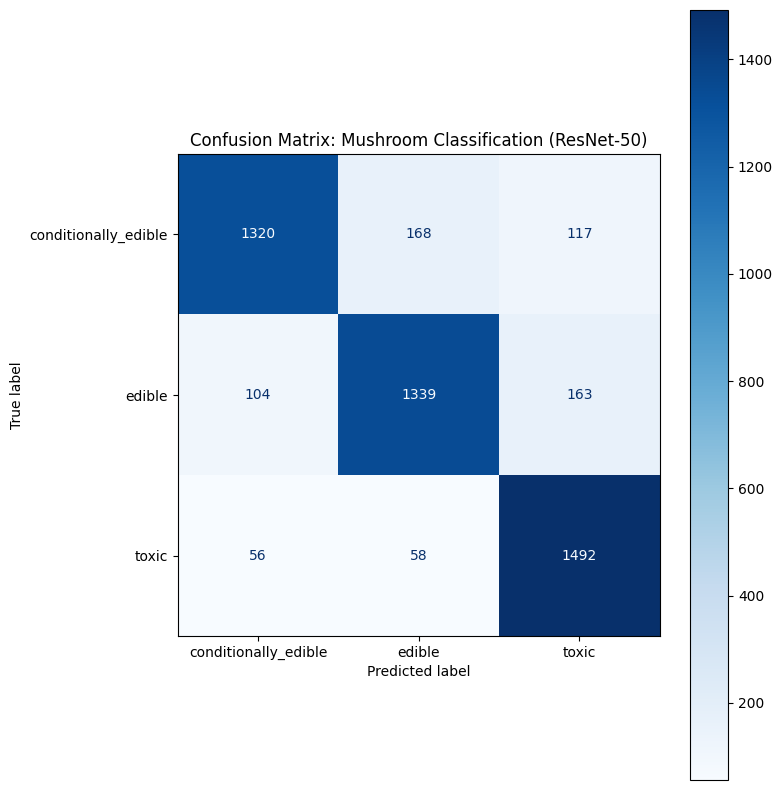

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Confusion Matrix: Mushroom Classification (ResNet-50)")
plt.tight_layout()
plt.savefig("resnet50_final_confusion_matrix.png", dpi=300)
plt.show()

torch.save(model.state_dict(), "Mushroom_ResNet50_Final.pth")